# Milestone 3, Task 3: Hyperparameter Sweep

This notebook varies the YOLOv8 fine-tuning and inference settings around the protocol of
[`Milestone3_YOLOv8_Training_Evaluation.ipynb`](../Milestone3_YOLOv8_Training_Evaluation.ipynb) (Tasks 1-2) and measures
how each change affects detection metrics. It covers **five** of the hyperparameters named in the assignment, in two parts:

| Part | Hyperparameters | Needs retraining | Selected on |
|---|---|---|---|
| A. Training sweep | learning rate, image size, augmentation intensity | yes, 1 run per configuration | validation mAP@0.5:0.95 |
| B. Inference sweep | confidence threshold, NMS IoU threshold (class-aware and class-agnostic NMS) | no, the selected model is re-run on cached predictions | validation F1 |

**Rules that keep the test split honest.** Every choice (best training configuration, operating point) is made on the
validation split. Test numbers are reported for every configuration so the trade-offs are visible, but they are never used
to pick anything.

**Outputs** (`results/milestone3/sweep/`): `sweep_training.csv`, `sweep_inference_val.csv`, `nms_map_val.csv`,
`operating_point.json`, figures `fig_*.png`, the selected checkpoint `best_model.pt` (used by the gallery and the demo),
and one folder per training run in `runs/` with the Ultralytics `results.csv` log and `args.yaml`.

**Running the notebook.** Run all cells. Part A trains 8 YOLOv8n models (about 5.5 hours on a laptop GeForce MX150 with 2 GB;
a Colab T4 should be considerably faster). A finished run writes `runs/<name>/done.json` and is skipped on the next run; an interrupted run
resumes from its last epoch. With all runs present, the whole notebook re-evaluates in a few minutes.

#### 0. Environment setup (local Jupyter or Google Colab)
On **Colab**: `Runtime -> Change runtime type -> T4 GPU`, then run this cell. It installs Ultralytics, mounts Google Drive
and uses (or clones) the repo at `MyDrive/IE7615-Group3-Project1` (cloning needs a GitHub token saved as the Colab secret
`GITHUB_TOKEN`). Locally (`pip install -r requirements.txt`), the cell just finds the repo root.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/rasmussenj03/IE7615-Group3-Project1.git"
COLAB_USE_DRIVE = True  # False -> clone into /content (outputs are lost when the runtime ends)
COLAB_REPO_DIR = ("/content/drive/MyDrive/IE7615-Group3-Project1" if COLAB_USE_DRIVE
                  else "/content/IE7615-Group3-Project1")

if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ultralytics>=8.3,<9"], check=True)
    if COLAB_USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
    if not Path(COLAB_REPO_DIR, "src").is_dir():
        from google.colab import userdata
        token = userdata.get("GITHUB_TOKEN")
        clone = subprocess.run(["git", "clone", "-q", REPO_URL.replace("https://", f"https://{token}@"),
                                COLAB_REPO_DIR], capture_output=True)
        if clone.returncode != 0:
            raise RuntimeError("git clone failed - check the GITHUB_TOKEN secret and repo access")
        subprocess.run(["git", "-C", COLAB_REPO_DIR, "remote", "set-url", "origin", REPO_URL])
    os.chdir(COLAB_REPO_DIR)
else:
    root = Path.cwd()
    while not (root / "src" / "detection_eval.py").exists() and root != root.parent:
        root = root.parent
    os.chdir(root)

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: C:\Users\masat\Documents\GitHub\IE7615-Group3-Project1


In [2]:
import json, re, shutil, time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import ultralytics
from IPython.display import display
from ultralytics import YOLO

from src import detection_eval as de

SWEEP_DIR = PROJECT_ROOT / "results" / "milestone3" / "sweep"
RUNS_DIR = SWEEP_DIR / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)
DATA_YAML = de.write_runtime_yaml(SWEEP_DIR)

DEVICE = 0 if torch.cuda.is_available() else "cpu"
# Mixed precision only pays off from Volta (compute capability 7.0) on; on older GPUs such as
# the GeForce MX/GTX 10xx series fp16 is much slower than fp32, so it is switched off there.
AMP = torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 7
print("Device:", torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU", "| AMP:", AMP)
print("ultralytics", ultralytics.__version__, "| torch", torch.__version__)

Device: NVIDIA GeForce MX150 | AMP: False
ultralytics 8.4.175 | torch 2.14.1+cu126


---
## Part A: Training sweep (learning rate, image size, augmentation)

**Design.** One factor at a time around a fixed baseline, instead of a full grid: 3 learning rates x 3 image sizes x
3 augmentation levels would be 27 runs, while varying one factor at a time costs 7 and still shows each factor's effect.
The baseline is the Task 1 protocol (COCO-pretrained YOLOv8n, all layers trained, AdamW, cosine decay to 1% of `lr0`,
3 warm-up epochs, weight decay 5e-4, seed 42, no online augmentation because the dataset already contains one augmented
copy of every image).

| Factor | Values (baseline in bold) | What we expect |
|---|---|---|
| Learning rate `lr0` | 1e-4, **1e-3**, 1e-2 | too low: the head adapts slowly; too high: AdamW overwrites the pretrained features |
| Image size `imgsz` | 320, 480, **640** | faces are 90-220 px in a 640 px image; at 320 they shrink to 45-110 px and lose identity detail, but inference is ~4x cheaper |
| Augmentation intensity | **none**, light, strong | more variety can reduce over-fitting to 300 training scenes, but too much (mosaic, mixup) changes face scale and appearance |

Augmentation levels (Ultralytics online augmentation, applied to training batches only):

| Level | Settings |
|---|---|
| none | all online augmentation off (Task 1 setting) |
| light | colour jitter `hsv_h=0.015, hsv_s=0.4, hsv_v=0.3`, horizontal flip 0.5, translate 0.1, scale ±25% |
| strong | Ultralytics defaults (`hsv_s=0.7, hsv_v=0.4`, flip 0.5, translate 0.1, scale ±50%, mosaic 1.0 switched off for the last 10 epochs) plus rotation ±10° and mixup 0.1 |

**Shared budget.** Every run gets the same budget of 30 epochs, with early stopping after 10 epochs without validation
improvement. This is shorter than Task 1 (150 / 30) so that 8 runs fit on a laptop GPU; the cosine schedule is stretched
over the 30 epochs, so the learning rate still decays fully and each run ends converged for its budget (checked in the
curves below). Absolute numbers can therefore be slightly below the Task 1 model; the sweep is about the *differences*
between configurations under equal conditions. Batch size 4 was the fastest setting on the 2 GB GPU; Ultralytics
accumulates gradients up to a nominal batch of 64 (`nbs`), so the effective batch is the same as in Task 1.
`baseline_seed1` repeats the baseline with another seed: differences between configurations smaller than the gap between
the two baseline seeds should not be read as real effects.

In [3]:
NO_AUG = dict(mosaic=0.0, mixup=0.0, copy_paste=0.0, degrees=0.0, translate=0.0, scale=0.0, shear=0.0,
              perspective=0.0, fliplr=0.0, flipud=0.0, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, close_mosaic=0)
LIGHT_AUG = NO_AUG | dict(hsv_h=0.015, hsv_s=0.4, hsv_v=0.3, fliplr=0.5, translate=0.1, scale=0.25)
STRONG_AUG = NO_AUG | dict(hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, fliplr=0.5, translate=0.1, scale=0.5,
                           degrees=10.0, mosaic=1.0, mixup=0.1, close_mosaic=10)

BASE = dict(model="yolov8n.pt", epochs=30, patience=10, imgsz=640, batch=4, optimizer="AdamW",
            lr0=1e-3, lrf=0.01, weight_decay=5e-4, cos_lr=True, warmup_epochs=3, seed=42,
            deterministic=True, cache="ram") | NO_AUG

# name: (factor, value shown in tables, overrides of BASE)
RUNS = {
    "baseline":       ("baseline", "lr 1e-3, 640 px, no aug", {}),
    "lr_1e-4":        ("learning rate", "1e-4", dict(lr0=1e-4)),
    "lr_1e-2":        ("learning rate", "1e-2", dict(lr0=1e-2)),
    "imgsz_320":      ("image size", "320", dict(imgsz=320)),
    "imgsz_480":      ("image size", "480", dict(imgsz=480)),
    "aug_light":      ("augmentation", "light", LIGHT_AUG),
    "aug_strong":     ("augmentation", "strong", STRONG_AUG),
    "baseline_seed1": ("seed check", "seed 1", dict(seed=1)),
}
pd.DataFrame([dict(run=k, factor=f, value=v, changes="see augmentation table" if f == "augmentation" else o)
              for k, (f, v, o) in RUNS.items()])

,run,factor,value,changes
0,baseline,baseline,"lr 1e-3, 640 px, no aug",{}
1,lr_1e-4,learning rate,1e-4,{'lr0': 0.0001}
2,lr_1e-2,learning rate,1e-2,{'lr0': 0.01}
3,imgsz_320,image size,320,{'imgsz': 320}
4,imgsz_480,image size,480,{'imgsz': 480}
5,aug_light,augmentation,light,see augmentation table
6,aug_strong,augmentation,strong,see augmentation table
7,baseline_seed1,seed check,seed 1,{'seed': 1}


In [4]:
# Each run trains in a child process whose console output goes to runs/<name>/train.log,
# so the notebook stays small and the full training log is kept with the run.
TRAIN_SCRIPT = ("import json, sys; from ultralytics import YOLO; "
                "a = json.load(open(sys.argv[1])); YOLO(a.pop('model')).train(**a)")

def clean_log(path):
    """Keep only the finished state (100%) of each progress bar, which is redrawn on every batch."""
    lines = [l.split("\r")[-1].replace("\x1b[K", "")
             for l in path.read_text(encoding="utf-8", errors="replace").split("\n")]
    partial = re.compile(r"\d+% [━╸─]")
    path.write_text("\n".join(l for l in lines if "100%" in l or not partial.search(l)), encoding="utf-8")

def train_run(name):
    """Train one configuration, skipping finished runs and resuming interrupted ones."""
    run_dir = RUNS_DIR / name
    if (run_dir / "done.json").is_file():
        print(f"{name}: done, skipping")
        return
    cfg = BASE | RUNS[name][2]
    last = run_dir / "weights" / "last.pt"
    if last.is_file():
        print(f"{name}: resuming from the last saved epoch")
        args = dict(model=str(last), resume=True)
    else:
        shutil.rmtree(run_dir, ignore_errors=True)
        run_dir.mkdir(parents=True)
        print(f"{name}: training ...")
        args = cfg | dict(data=str(DATA_YAML), device=DEVICE, amp=AMP, workers=0, val=True, plots=False,
                          project=str(RUNS_DIR), name=name, exist_ok=True)
    (run_dir / "train_args.json").write_text(json.dumps(args, indent=2))
    start = time.time()
    with open(run_dir / "train.log", "a", encoding="utf-8") as log:
        subprocess.run([sys.executable, "-c", TRAIN_SCRIPT, str(run_dir / "train_args.json")], stdout=log,
                       stderr=subprocess.STDOUT, check=True, env=os.environ | {"PYTHONIOENCODING": "utf-8"})
    clean_log(run_dir / "train.log")
    (run_dir / "train_args.json").unlink()
    minutes = (time.time() - start) / 60
    (run_dir / "done.json").write_text(json.dumps({"config": cfg, "train_minutes": round(minutes, 1)}, indent=2))
    print(f"{name}: finished in {minutes:.0f} min")

for name in RUNS:
    train_run(name)

baseline: done, skipping
lr_1e-4: done, skipping
lr_1e-2: done, skipping
imgsz_320: done, skipping
imgsz_480: done, skipping
aug_light: done, skipping
aug_strong: done, skipping
baseline_seed1: done, skipping


### A.1 Evaluate every configuration

Each run's `best.pt` (selected by Ultralytics on validation fitness) is evaluated on validation and test with the same
settings as Task 2: AP/mAP with a 0.001 confidence floor and NMS IoU 0.7; precision, recall, F1 and mean matched IoU at
the fixed reporting threshold (confidence 0.25, TP match IoU 0.5). Inference time is the Ultralytics test-set timing on the GeForce MX150
(fp32, batch 8) at the run's own image size; read it as a relative comparison between configurations. Results are cached in `runs/<name>/eval.json`.

In [5]:
REPORT_CONF, NMS_IOU = 0.25, 0.70
VAL_IMAGES, TEST_IMAGES = de.split_images("val"), de.split_images("test")

def evaluate_run(name):
    run_dir = RUNS_DIR / name
    cache = run_dir / "eval.json"
    if cache.is_file():
        return json.loads(cache.read_text())
    cfg = json.loads((run_dir / "done.json").read_text())["config"]
    model = YOLO(str(run_dir / "weights" / "best.pt"))
    row = {}
    for split, images in [("val", VAL_IMAGES), ("test", TEST_IMAGES)]:
        m = model.val(data=str(DATA_YAML), split=split, imgsz=cfg["imgsz"], batch=8, conf=0.001, iou=NMS_IOU,
                      device=DEVICE, workers=0, plots=False, verbose=False, project=str(SWEEP_DIR / "_val"),
                      name=name, exist_ok=True)
        row[f"{split}_mAP50"], row[f"{split}_mAP50_95"] = float(m.box.map50), float(m.box.map)
        records = de.predict_split(model, images, nms_iou=NMS_IOU, imgsz=cfg["imgsz"], device=DEVICE)
        overall, _ = de.evaluate(records, REPORT_CONF)
        for k in ("precision", "recall", "F1", "mean_matched_IoU"):
            row[f"{split}_{k}"] = overall[k]
        if split == "test":
            row["ms_per_image"] = float(m.speed["inference"])
    cache.write_text(json.dumps(row, indent=2))
    return row

rows = []
for name, (factor, value, _) in RUNS.items():
    hist = pd.read_csv(RUNS_DIR / name / "results.csv")
    hist.columns = hist.columns.str.strip()
    best = hist.loc[hist["metrics/mAP50-95(B)"].idxmax()]
    rows.append(dict(run=name, factor=factor, value=value, epochs_run=len(hist), best_epoch=int(best["epoch"]),
                     train_minutes=round(hist["time"].iloc[-1] / 60, 1), **evaluate_run(name)))
sweep = pd.DataFrame(rows)
sweep.to_csv(SWEEP_DIR / "sweep_training.csv", index=False)
shutil.rmtree(SWEEP_DIR / "_val", ignore_errors=True)

cols = ["run", "factor", "value", "epochs_run", "best_epoch", "train_minutes", "val_mAP50", "val_mAP50_95",
        "test_mAP50", "test_mAP50_95", "test_precision", "test_recall", "test_F1", "test_mean_matched_IoU",
        "ms_per_image"]
display(sweep[cols].style.format(precision=3).background_gradient(
    subset=["val_mAP50_95", "test_mAP50_95"], cmap="Greens"))

,run,factor,value,epochs_run,best_epoch,train_minutes,val_mAP50,val_mAP50_95,test_mAP50,test_mAP50_95,test_precision,test_recall,test_F1,test_mean_matched_IoU,ms_per_image
0,baseline,baseline,"lr 1e-3, 640 px, no aug",30,28,49.400,0.961,0.914,0.964,0.915,0.895,0.947,0.920,0.962,78.167
1,lr_1e-4,learning rate,1e-4,25,15,40.400,0.909,0.846,0.900,0.834,0.774,0.871,0.820,0.954,83.053
2,lr_1e-2,learning rate,1e-2,30,24,47.800,0.923,0.862,0.941,0.870,0.858,0.912,0.884,0.953,75.595
3,imgsz_320,image size,320,23,13,12.200,0.971,0.879,0.921,0.827,0.838,0.899,0.868,0.942,35.264
4,imgsz_480,image size,480,23,13,22.500,0.967,0.905,0.910,0.847,0.813,0.871,0.841,0.954,45.604
5,aug_light,augmentation,light,30,29,52.100,0.991,0.965,0.975,0.944,0.832,0.956,0.889,0.969,79.428
6,aug_strong,augmentation,strong,30,25,51.200,0.989,0.929,0.984,0.905,0.880,0.971,0.923,0.942,81.786
7,baseline_seed1,seed check,seed 1,30,30,50.200,0.961,0.918,0.964,0.913,0.883,0.934,0.908,0.961,78.112


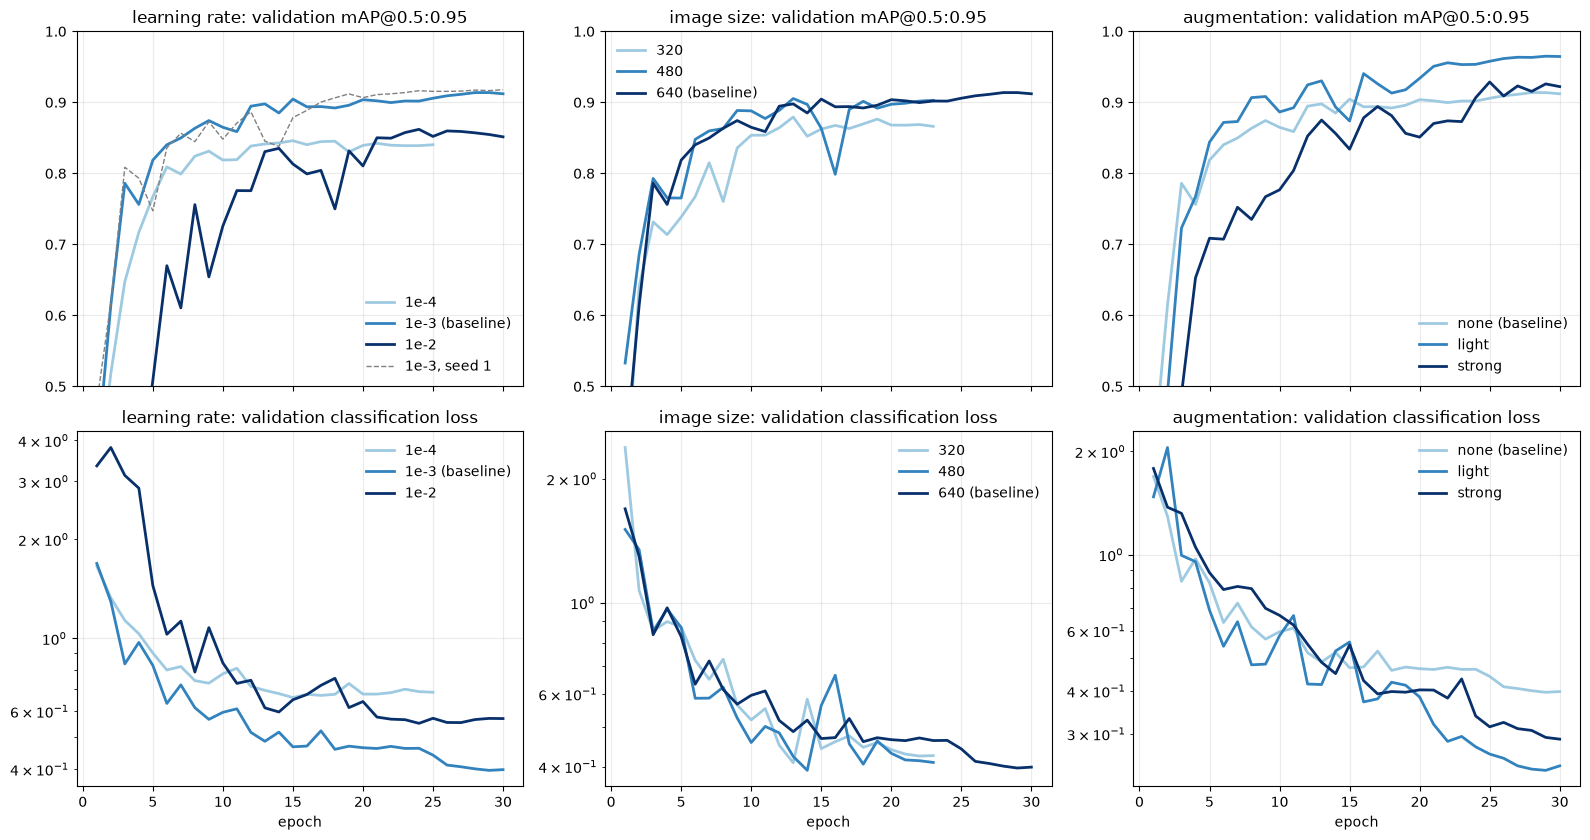

In [6]:
GROUPS = [("learning rate", ["lr_1e-4", "baseline", "lr_1e-2"], ["1e-4", "1e-3 (baseline)", "1e-2"]),
          ("image size", ["imgsz_320", "imgsz_480", "baseline"], ["320", "480", "640 (baseline)"]),
          ("augmentation", ["baseline", "aug_light", "aug_strong"], ["none (baseline)", "light", "strong"])]
SHADES = ["#9ecae1", "#3182bd", "#08306b"]

def history(name):
    h = pd.read_csv(RUNS_DIR / name / "results.csv")
    h.columns = h.columns.str.strip()
    return h

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), sharex=True)
for col, (factor, names, labels) in enumerate(GROUPS):
    for name, label, color in zip(names, labels, SHADES):
        h = history(name)
        axes[0, col].plot(h["epoch"], h["metrics/mAP50-95(B)"], color=color, lw=2, label=label)
        axes[1, col].plot(h["epoch"], h["val/cls_loss"], color=color, lw=2, label=label)
    if factor == "learning rate":
        h = history("baseline_seed1")
        axes[0, col].plot(h["epoch"], h["metrics/mAP50-95(B)"], color="grey", lw=1, ls="--", label="1e-3, seed 1")
    axes[0, col].set(title=f"{factor}: validation mAP@0.5:0.95", ylim=(0.5, 1.0))
    axes[1, col].set(title=f"{factor}: validation classification loss", xlabel="epoch")
    axes[1, col].set_yscale("log")
    for ax in axes[:, col]:
        ax.grid(alpha=0.25); ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(SWEEP_DIR / "fig_training_curves.png", dpi=150)
plt.show()

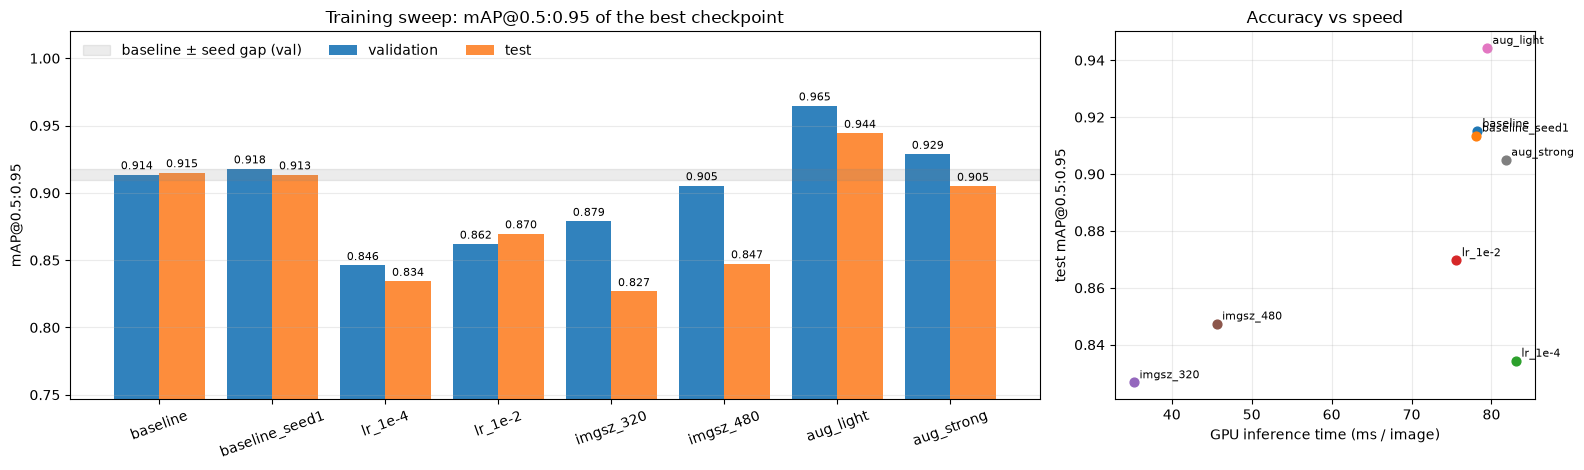

In [7]:
order = ["baseline", "baseline_seed1", "lr_1e-4", "lr_1e-2", "imgsz_320", "imgsz_480", "aug_light", "aug_strong"]
s = sweep.set_index("run").loc[order]
x = np.arange(len(order))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.8), gridspec_kw=dict(width_ratios=[3, 1.3]))
ax1.bar(x - 0.2, s["val_mAP50_95"], 0.4, color="#3182bd", label="validation")
ax1.bar(x + 0.2, s["test_mAP50_95"], 0.4, color="#fd8d3c", label="test")
for xi, (v, t) in enumerate(zip(s["val_mAP50_95"], s["test_mAP50_95"])):
    ax1.text(xi - 0.2, v + 0.004, f"{v:.3f}", ha="center", fontsize=8)
    ax1.text(xi + 0.2, t + 0.004, f"{t:.3f}", ha="center", fontsize=8)
seed_gap = abs(s.loc["baseline", "val_mAP50_95"] - s.loc["baseline_seed1", "val_mAP50_95"])
ax1.axhspan(s.loc["baseline", "val_mAP50_95"] - seed_gap, s.loc["baseline", "val_mAP50_95"] + seed_gap,
            color="grey", alpha=0.15, label="baseline ± seed gap (val)")
ax1.set_xticks(x, order, rotation=20)
ax1.set(ylabel="mAP@0.5:0.95", ylim=(max(0, s[["val_mAP50_95", "test_mAP50_95"]].min().min() - 0.08), 1.02),
        title="Training sweep: mAP@0.5:0.95 of the best checkpoint")
ax1.legend(frameon=False, loc="upper left", ncol=3); ax1.grid(axis="y", alpha=0.25)
for name in order:
    ax2.scatter(s.loc[name, "ms_per_image"], s.loc[name, "test_mAP50_95"], s=40)
    ax2.annotate(name, (s.loc[name, "ms_per_image"], s.loc[name, "test_mAP50_95"]), fontsize=8,
                 xytext=(4, 3), textcoords="offset points")
ax2.set(xlabel="GPU inference time (ms / image)", ylabel="test mAP@0.5:0.95", title="Accuracy vs speed")
ax2.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(SWEEP_DIR / "fig_training_sweep.png", dpi=150)
plt.show()

### A.2 Select the training configuration

The configuration with the highest **validation** mAP@0.5:0.95 is selected. Its checkpoint is copied to
`results/milestone3/sweep/best_model.pt` (about 6 MB, committed to the repo), which the gallery (Task 4) and the demo will use.

In [8]:
SELECTED = sweep.loc[sweep["val_mAP50_95"].idxmax(), "run"]
SELECTED_CFG = json.loads((RUNS_DIR / SELECTED / "done.json").read_text())["config"]
BEST_MODEL = SWEEP_DIR / "best_model.pt"
shutil.copy2(RUNS_DIR / SELECTED / "weights" / "best.pt", BEST_MODEL)
print(f"Selected configuration: {SELECTED} (imgsz {SELECTED_CFG['imgsz']}, lr0 {SELECTED_CFG['lr0']})")
display(sweep.set_index("run").loc[[SELECTED], cols[3:]].round(4))

Selected configuration: aug_light (imgsz 640, lr0 0.001)


,epochs_run,best_epoch,train_minutes,val_mAP50,val_mAP50_95,test_mAP50,test_mAP50_95,test_precision,test_recall,test_F1,test_mean_matched_IoU,ms_per_image
run,,,,,,,,,,,,
aug_light,30,29,52.1,0.9911,0.9647,0.9745,0.9443,0.8317,0.9558,0.8895,0.9691,79.4277


---
## Part B: Inference sweep (confidence threshold, NMS IoU threshold)

These two thresholds do not change the model, only which of its boxes are kept:

* **Confidence threshold:** boxes scoring below it are dropped. Higher means fewer false positives (precision up) but
  more missed faces (recall down).
* **NMS IoU threshold:** after prediction, a box is suppressed when it overlaps a higher-scoring box by more than this
  IoU. Lower values remove duplicates more aggressively but could also remove a neighbouring face.
* **Class-aware vs class-agnostic NMS:** by default (class-aware) NMS only compares boxes of the same identity, so the
  model can return two boxes with different names on the same face. Class-agnostic NMS keeps only the highest-scoring
  identity per location, which suits our data: every face belongs to exactly one person.

The selected model predicts the validation split once per NMS setting with a 0.001 confidence floor; all confidence
thresholds are then applied to these cached boxes, which gives exactly the same boxes as re-running the model with that
threshold (see `src/detection_eval.py`). Precision, recall and F1 use the Task 2 matching protocol.

In [9]:
best_model = YOLO(str(BEST_MODEL))
IMGSZ = SELECTED_CFG["imgsz"]
CONF_GRID = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
NMS_GRID = [0.30, 0.45, 0.60, 0.70, 0.85]

rows, val_cache = [], {}
for agnostic in (False, True):
    for nms in NMS_GRID:
        recs = de.predict_split(best_model, VAL_IMAGES, nms_iou=nms, agnostic_nms=agnostic, imgsz=IMGSZ, device=DEVICE)
        val_cache[(nms, agnostic)] = recs
        for conf in CONF_GRID:
            overall, _ = de.evaluate(recs, conf)
            rows.append(dict(nms_iou=nms, agnostic_nms=agnostic, conf=conf, **overall))
inf = pd.DataFrame(rows)
inf.to_csv(SWEEP_DIR / "sweep_inference_val.csv", index=False)
show = ["conf", "TP", "FP", "FN", "precision", "recall", "F1", "mean_matched_IoU",
        "wrong_identity", "duplicate", "poor_localization", "background", "missed"]
print("Validation, NMS IoU 0.7, class-aware NMS (the Task 2 setting):")
display(inf[(inf.nms_iou == 0.7) & ~inf.agnostic_nms][show].round(3))

Validation, NMS IoU 0.7, class-aware NMS (the Task 2 setting):


,conf,TP,FP,FN,precision,recall,F1,mean_matched_IoU,wrong_identity,duplicate,poor_localization,background,missed
36,0.05,553,73,11,0.883,0.980,0.929,0.970,39,2,1,31,0
37,0.10,553,57,11,0.907,0.980,0.942,0.970,36,1,0,20,0
38,0.15,553,49,11,0.919,0.980,0.949,0.970,33,1,0,15,1
39,0.20,552,41,12,0.931,0.979,0.954,0.970,30,0,0,11,2
40,0.25,552,39,12,0.934,0.979,0.956,0.970,30,0,0,9,2
41,0.30,552,36,12,0.939,0.979,0.958,0.970,28,0,0,8,2
42,0.40,551,31,13,0.947,0.977,0.962,0.970,26,0,0,5,3
43,0.50,545,26,19,0.954,0.966,0.960,0.972,22,0,0,4,7
44,0.60,543,16,21,0.971,0.963,0.967,0.972,15,0,0,1,10
45,0.70,542,12,22,0.978,0.961,0.970,0.973,12,0,0,0,14


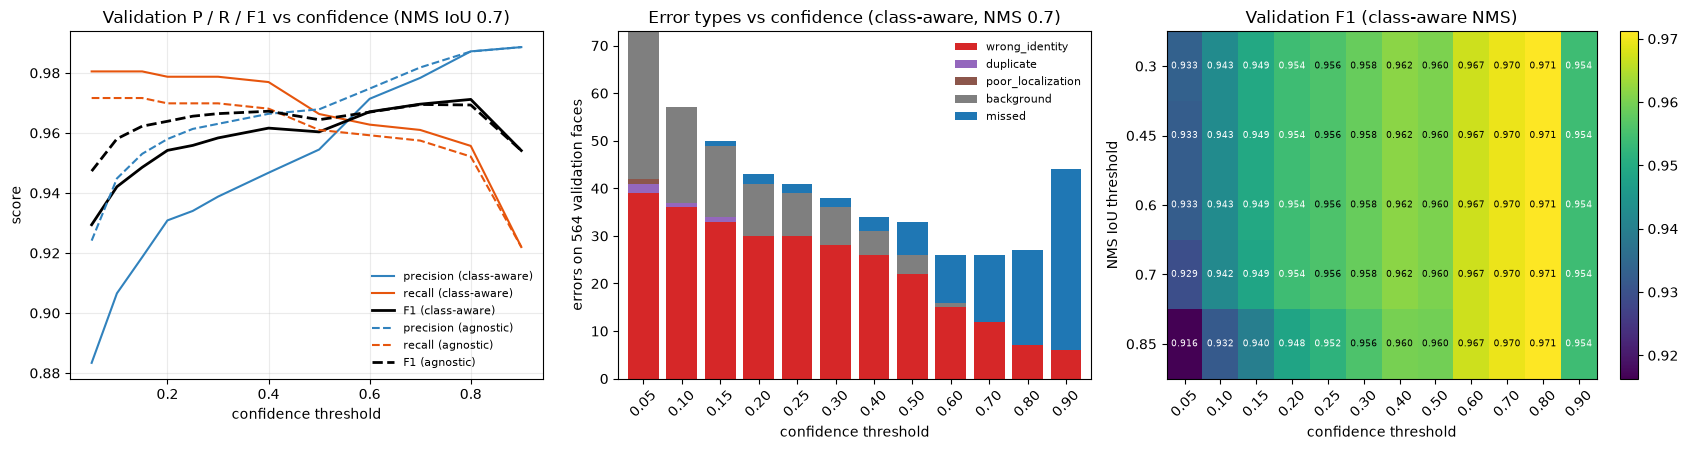

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
ax = axes[0]
for agnostic, ls in [(False, "-"), (True, "--")]:
    d = inf[(inf.nms_iou == 0.7) & (inf.agnostic_nms == agnostic)]
    tag = "agnostic" if agnostic else "class-aware"
    ax.plot(d.conf, d.precision, ls, color="#3182bd", label=f"precision ({tag})")
    ax.plot(d.conf, d.recall, ls, color="#e6550d", label=f"recall ({tag})")
    ax.plot(d.conf, d.F1, ls, color="black", lw=2, label=f"F1 ({tag})")
ax.set(xlabel="confidence threshold", ylabel="score", title="Validation P / R / F1 vs confidence (NMS IoU 0.7)")
ax.grid(alpha=0.25); ax.legend(frameon=False, fontsize=8)

ax = axes[1]
d = inf[(inf.nms_iou == 0.7) & ~inf.agnostic_nms].set_index("conf")
d[["wrong_identity", "duplicate", "poor_localization", "background", "missed"]].plot.bar(
    stacked=True, ax=ax, color=["#d62728", "#9467bd", "#8c564b", "#7f7f7f", "#1f77b4"], width=0.8)
ax.set(xlabel="confidence threshold", ylabel="errors on 564 validation faces",
       title="Error types vs confidence (class-aware, NMS 0.7)")
ax.set_xticklabels([f"{c:.2f}" for c in d.index], rotation=45); ax.legend(frameon=False, fontsize=8)

ax = axes[2]
grid = inf[~inf.agnostic_nms].pivot(index="nms_iou", columns="conf", values="F1")
im = ax.imshow(grid.values, cmap="viridis", aspect="auto", vmin=max(0.0, grid.values.min()), vmax=grid.values.max())
ax.set_xticks(range(len(grid.columns)), [f"{c:.2f}" for c in grid.columns], rotation=45)
ax.set_yticks(range(len(grid.index)), grid.index)
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        ax.text(j, i, f"{grid.values[i, j]:.3f}", ha="center", va="center", fontsize=6.5,
                color="white" if grid.values[i, j] < grid.values.mean() else "black")
ax.set(xlabel="confidence threshold", ylabel="NMS IoU threshold", title="Validation F1 (class-aware NMS)")
fig.colorbar(im, ax=ax, fraction=0.04)
fig.tight_layout()
fig.savefig(SWEEP_DIR / "fig_inference_sweep.png", dpi=150)
plt.show()

**NMS IoU and mAP.** mAP integrates over all confidence thresholds, so it is not affected by the confidence threshold,
but it is affected by NMS. The table below re-runs the Ultralytics validation of the selected model at every NMS setting.

In [11]:
rows = []
for agnostic in (False, True):
    for nms in NMS_GRID:
        m = best_model.val(data=str(DATA_YAML), split="val", imgsz=IMGSZ, batch=8, conf=0.001, iou=nms,
                           agnostic_nms=agnostic, device=DEVICE, workers=0, plots=False, verbose=False,
                           project=str(SWEEP_DIR / "_val"), name="nms", exist_ok=True)
        rows.append(dict(nms_iou=nms, agnostic_nms=agnostic, val_mAP50=m.box.map50, val_mAP50_95=m.box.map))
shutil.rmtree(SWEEP_DIR / "_val", ignore_errors=True)
nms_map = pd.DataFrame(rows)
nms_map.to_csv(SWEEP_DIR / "nms_map_val.csv", index=False)
display(nms_map.pivot(index="nms_iou", columns="agnostic_nms", values=["val_mAP50", "val_mAP50_95"]).round(4))

Ultralytics 8.4.175  Python-3.13.9 torch-2.14.1+cu126 CUDA:0 (NVIDIA GeForce MX150, 2048MiB)


Model summary (fused): 73 layers, 3,133,436 parameters, 0 gradients, 8.6 GFLOPs


val: Fast image access  (ping: 0.10.0 ms, read: 541.1140.5 MB/s, size: 75.0 KB)



val: Scanning C:\Users\masat\Documents\GitHub\IE7615-Group3-Project1\data\detection\labels\val.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 6.8Mit/s 0.0s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 4% ──────────── 1/25 1.1s/it 0.3s<27.4s

...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 96% ━━━━━━━━━━━╸ 24/25 4.1it/s 5.9s<0.2s


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 4.1it/s 6.2s

                   all        200        564      0.981      0.953      0.968      0.941


Speed: 1.0ms preprocess, 21.0ms inference, 0.0ms loss, 1.7ms postprocess per image


val_mAP50         val_mAP50_95        
agnostic_nms     False   True         False   True 
nms_iou                                            
0.30            0.9912  0.9638       0.9643  0.9378
0.45            0.9912  0.9638       0.9642  0.9378
0.60            0.9912  0.9661       0.9647  0.9387
0.70            0.9911  0.9679       0.9647  0.9394
0.85            0.9907  0.9680       0.9651  0.9408

### B.1 Select the operating point and check it once on test

The operating point with the highest validation F1 is chosen (ties go to the higher confidence threshold, which gives
fewer false alarms, and then to the NMS setting closest to the Task 2 default of 0.7, because a tie means the data give
no reason to change it). It is saved to `operating_point.json` for the gallery and the demo. The test split is then evaluated
once at the Task 2 default (confidence 0.25, NMS IoU 0.7, class-aware) and once at the selected operating point.

In [12]:
best = inf.assign(nms_distance=(inf.nms_iou - 0.7).abs()).sort_values(
    ["F1", "conf", "nms_distance"], ascending=[False, False, True]).iloc[0]
OP = dict(model=str(BEST_MODEL.relative_to(PROJECT_ROOT)).replace("\\", "/"), training_run=SELECTED, imgsz=IMGSZ,
          conf=float(best.conf), nms_iou=float(best.nms_iou), agnostic_nms=bool(best.agnostic_nms),
          selected_on="validation F1")
(SWEEP_DIR / "operating_point.json").write_text(json.dumps(OP, indent=2))
print("Selected operating point:", OP)

rows = []
for label, conf, nms, agnostic in [("Task 2 default", 0.25, 0.70, False),
                                   ("selected on validation", OP["conf"], OP["nms_iou"], OP["agnostic_nms"])]:
    for split, images in [("val", VAL_IMAGES), ("test", TEST_IMAGES)]:
        recs = val_cache[(nms, agnostic)] if split == "val" else de.predict_split(
            best_model, images, nms_iou=nms, agnostic_nms=agnostic, imgsz=IMGSZ, device=DEVICE)
        overall, per_class = de.evaluate(recs, conf)
        rows.append(dict(setting=label, split=split, conf=conf, nms_iou=nms, agnostic_nms=agnostic, **overall))
        if split == "test" and label != "Task 2 default":
            test_per_class = pd.DataFrame(per_class).T
op_table = pd.DataFrame(rows)
op_table.to_csv(SWEEP_DIR / "operating_point_comparison.csv", index=False)
display(op_table.round(4))
print("Per-identity test results at the selected operating point:")
display(test_per_class.round(4))

Selected operating point: {'model': 'results/milestone3/sweep/best_model.pt', 'training_run': 'aug_light', 'imgsz': 640, 'conf': 0.8, 'nms_iou': 0.7, 'agnostic_nms': False, 'selected_on': 'validation F1'}


,setting,split,conf,nms_iou,agnostic_nms,TP,FP,FN,precision,recall,F1,mean_matched_IoU,wrong_identity,duplicate,poor_localization,background,missed
0,Task 2 default,val,0.25,0.7,False,552,39,12,0.9340,0.9787,0.9558,0.9700,30,0,0,9,2
1,Task 2 default,test,0.25,0.7,False,519,105,24,0.8317,0.9558,0.8895,0.9691,42,0,0,63,5
2,selected on validation,val,0.80,0.7,False,539,7,25,0.9872,0.9557,0.9712,0.9725,7,0,0,0,20
3,selected on validation,test,0.80,0.7,False,499,18,44,0.9652,0.9190,0.9415,0.9707,16,0,0,2,28


Per-identity test results at the selected operating point:


,TP,FP,FN,precision,recall,F1,mean_matched_IoU
id_2336,136.0,4.0,6.0,0.9714,0.9577,0.9645,0.9702
id_2970,137.0,2.0,5.0,0.9856,0.9648,0.9751,0.9705
id_4422,120.0,11.0,9.0,0.9160,0.9302,0.9231,0.9725
id_7007,106.0,1.0,24.0,0.9907,0.8154,0.8945,0.9694


---
## Summary and interpretation

All numbers are mAP@0.5:0.95 of each run's best checkpoint unless stated otherwise (validation / test).

| Run | Changed | Val mAP@0.5:0.95 | Test mAP@0.5:0.95 | Test mAP@0.5 | Train time (MX150) | Inference |
|---|---|---|---|---|---|---|
| baseline | lr 1e-3, 640 px, no online aug | 0.914 | 0.915 | 0.964 | 49 min | 78 ms |
| baseline_seed1 | seed 1 | 0.918 | 0.913 | 0.964 | 50 min | 78 ms |
| lr_1e-4 | learning rate | 0.846 | 0.834 | 0.900 | 40 min (early stop) | 83 ms |
| lr_1e-2 | learning rate | 0.862 | 0.870 | 0.941 | 48 min | 76 ms |
| imgsz_320 | image size | 0.879 | 0.827 | 0.921 | 12 min (early stop) | 35 ms |
| imgsz_480 | image size | 0.905 | 0.847 | 0.910 | 23 min (early stop) | 46 ms |
| **aug_light** | augmentation | **0.965** | **0.944** | 0.975 | 52 min | 79 ms |
| aug_strong | augmentation | 0.929 | 0.905 | 0.984 | 51 min | 82 ms |

**Run-to-run noise.** The two baseline seeds differ by 0.004 (validation) and 0.002 (test). Differences of a few
thousandths are noise; every factor below moves mAP by at least 0.01.

**Learning rate: 1e-3 is clearly best.** At **1e-4** the model improves quickly for 6 epochs and then stalls: validation
mAP stays at about 0.84 from epoch 13, the validation classification loss stays near 0.7 (baseline 0.4), and early
stopping ends the run at epoch 25. The step size is too small to adapt the COCO features to the four new identities
within the budget. At **1e-2** training starts unstable: the validation classification loss is 3-4 in the first 4 epochs (baseline
below 1.7) and mAP swings between 0.6 and 0.85 until about epoch 20. AdamW with this step size overwrites much of the pretrained backbone, and the run only recovers part of it as the
cosine schedule lowers the learning rate (0.862). Both extremes lose 0.05-0.07 mAP.

**Image size: smaller images keep detection but lose identity and localization.** At 320 px the faces are 45-110 px,
and validation **mAP@0.5 is unchanged** (0.971 vs 0.961): faces are still found and named. mAP@0.5:0.95 drops to 0.879,
though, because boxes are less precise when every feature-map cell covers twice as many image pixels in each
direction. The test drop is larger
(0.827), so the low-resolution models generalize worse to the unseen test rooms and faces. The benefit is speed: 320 px
runs at 35 ms per image (2.2x faster) and trains 4x faster. 640 px is the right choice for accuracy; 480 px would only
be worth it for a speed-limited demo.

**Augmentation intensity: light augmentation is the biggest single gain in the sweep (+0.051 validation, +0.029
test).** Colour jitter, flips and ±25% scale/translate mean that every epoch sees slightly different versions of the 300
training scenes. The validation classification loss reaches 0.27 instead of 0.40, so identities are separated better,
and validation mAP keeps improving until epoch 29. **Strong augmentation** (mosaic, mixup, rotation, ±50% scale) is worse during
training: mosaic shrinks faces to a quarter of the image and mixup blends two faces, so the model trains on images unlike
the test images. Its validation mAP stays around 0.85-0.87 for epochs 12-20, and only reaches 0.929 once mosaic is switched off
for the last 10 epochs. With 30 epochs that is not enough to catch up, and it is below the baseline on test (0.905). It does have
the highest test mAP@0.5 (0.984): it finds faces very reliably, but its boxes are less tight.

**Selected configuration: `aug_light`** (highest validation mAP). In 30 epochs it reaches test mAP@0.5:0.95 **0.944**
and mAP@0.5 0.975. That is on par with the Task 1 model, which trained up to 150 epochs without online augmentation
(test 0.941 / 0.983, best epoch 50). The validation-to-test gap is larger than for the baseline (0.021 vs -0.001),
mostly from false alarms on the unseen test rooms (see below). A natural Milestone 4 step is to retrain `aug_light` with
the Task 1 budget of 150 epochs, since it was still improving at the end of the 30-epoch budget.

**Confidence threshold: the main precision / recall control.** On validation, F1 rises from 0.929 at confidence 0.05
to its maximum of **0.971 at 0.80**, then falls at 0.90 as recall collapses (missed faces 20 → 38). At low thresholds
the false positives are wrong identities (39 at 0.05) and boxes on background (31). Background boxes disappear above
0.6, but **wrong identities persist even at 0.8 (7 boxes)**: these are confident confusions between people, not
uncertain detections.

**NMS IoU threshold: almost no effect on this dataset.** For NMS IoU 0.3-0.7, P, R and F1 are *identical* at every
confidence threshold from 0.15 up, and validation mAP varies by only 0.001 (0.964-0.965) across all five settings. Only
the loosest setting (0.85) lets a few extra overlapping boxes through below confidence 0.5 (F1 0.916 vs 0.929 at 0.05,
0.952 vs 0.956 at 0.25). Above 0.5 all five settings give the same boxes. This is
expected: in Milestone 2 faces were placed without overlap, so NMS never has to separate two neighbouring faces. NMS
would matter much more on real group photos with overlapping faces, which this benchmark does not test.

**Class-aware vs class-agnostic NMS: a real trade-off.** Class-agnostic NMS keeps one identity per face, which halves
the wrong-identity boxes at confidence 0.25 (30 → 15) and raises F1 (0.956 → 0.966). It **lowers mAP**, though
(0.965 → 0.939 at NMS 0.7), because AP rewards keeping the model's second guess: when the top identity is wrong, the
lower-scored correct box still counts. At the selected confidence of 0.8 the two give practically the same result, so
we keep class-aware NMS, which keeps mAP comparable with Task 2.

**Selected operating point and its test check** (`operating_point.json`): confidence **0.80**, NMS IoU **0.70**,
class-aware NMS. On test it raises precision from 0.832 to **0.965** at the cost of recall (0.956 → **0.919**), and F1
from 0.890 to **0.942**; mean matched IoU stays at 0.97. The default threshold of 0.25 works much worse on test than on
validation (105 vs 39 false positives), mainly because of **63 boxes on no labelled face**
(validation: 9). The gallery (Task 4) shows what they are. **46 lie inside the image, on chair backrests:** two test
rooms have rows of face-sized, roughly oval chair backs at head height, and the model scores them up to 0.73, mostly as
id_7007; this was the case in all 12 such images we inspected. **17 lie on the border of augmented images,** where a
face cut by the crop loses its label once less than 30% of its box is visible (Milestone 2's `min_visibility` rule), so
some of these "false positives" are actually correct detections. The higher threshold, chosen on validation without
seeing any of this, removes all but 2, and both remaining ones are on augmented-image borders. The recall
cost falls mostly on **id_7007** (test recall 0.815; 24 of the 44 missed or mislabelled faces). Its faces are usually
still boxed, but at 0.6-0.8 and often split between id_7007 and id_4422, so the threshold removes them. id_4422 has the
lowest precision (0.916): all 11 of its false positives are other people, 7 of them id_7007 and 4 id_2970 (id_2970 /
id_4422 is the look-alike pair from Milestone 1; id_7007 → id_4422 is the detector's most frequent confusion). Gallery examples of these
errors are in `results/milestone3/gallery/` (Task 4).

**Limits.** One seed per configuration (the seed check shows ±0.004), one factor varied at a time (interactions such as
light augmentation at 480 px are not tested), a 30-epoch budget, and a synthetic test set with non-overlapping faces.